In [ ]:
!rm -r TrajectoryNet/

In [1]:
# 1. Clone repository
!git clone https://github.com/tareksaade99/TrajectoryNet.git
%cd TrajectoryNet

# 2. Install in editable mode
!pip install -e .  # -e = editable mode

# 3. Install dependencies
!pip install -r requirements.txt

# 4. Enable autoreload
%load_ext autoreload
%autoreload 2  # Reload modules automatically


Cloning into 'TrajectoryNet'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 319 (delta 169), reused 283 (delta 134), pack-reused 0 (from 0)
Receiving objects: 100% (319/319), 37.29 MiB | 19.42 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/TrajectoryNet
Obtaining file:///content/TrajectoryNet
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class ArcDataGenerator:
    def __init__(self, n_per_class=5000, noise_r=0.02, noise_theta=0.1, num_timepoints=3):
        self.n_per_class = n_per_class
        self.noise_r = noise_r
        self.noise_theta = noise_theta
        self.num_timepoints = num_timepoints
        self.data = None
        self.velocities = None
        self.labels = None

    def generate_arc_data(self, filename="arc_data.npz", seed=42):
        """Generate artificial arc data with positions and velocities"""
        np.random.seed(seed)

        # Create timepoint labels
        self.labels = np.repeat(np.arange(self.num_timepoints), self.n_per_class)

        # Base angles (theta) for arc
        theta = self.labels * (np.pi / (self.num_timepoints - 1))
        theta += np.random.randn(*theta.shape) * self.noise_theta

        # Reflect values to keep theta within [0, π]
        theta[theta < 0] *= -1
        theta[theta > np.pi] = 2 * np.pi - theta[theta > np.pi]

        # Radii with noise
        r = (1 + np.random.randn(*theta.shape) * self.noise_r)[:, None]
        r = np.repeat(r, 2, axis=1)

        # 2D arc coordinates
        self.data = np.array([np.cos(theta), np.sin(theta)]).T * r

        # Simulate a forward step in time to get velocities
        theta_next = theta + 1.3
        next2d = np.array([np.cos(theta_next), np.sin(theta_next)]).T * r
        self.velocities = next2d - self.data

        # Save to npz
        np.savez(
            filename,
            phate=self.data,
            delta_phate=self.velocities,
            sample_labels=self.labels
        )

        print(f"Saved arc-shaped data with {self.num_timepoints} timepoints to {filename}")
        return self.data, self.velocities, self.labels

    def get_velocity(self, point_indices=None):
        """Get velocity vectors for specified points or all points"""
        if self.velocities is None:
            raise ValueError("No data generated yet. Call generate_arc_data() first.")

        if point_indices is None:
            return self.velocities
        else:
            return self.velocities[point_indices]

    def get_velocity_magnitude(self, point_indices=None):
        """Get velocity magnitudes for specified points"""
        velocities = self.get_velocity(point_indices)
        return np.linalg.norm(velocities, axis=1)

    def get_velocity_direction(self, point_indices=None):
        """Get velocity directions (angles) for specified points"""
        velocities = self.get_velocity(point_indices)
        return np.arctan2(velocities[:, 1], velocities[:, 0])

    def visualize_data(self, velocity_scale=1, figsize=(10, 8)):
        """Visualize the arc data with velocity arrows for different timepoints"""
        if self.data is None:
            raise ValueError("No data generated yet. Call generate_arc_data() first.")

        colors = plt.cm.viridis(np.linspace(0, 1, self.num_timepoints))
        fig, ax = plt.subplots(1, 1, figsize=figsize)

        # Subsample for cleaner visualization
        subsample_idx = np.random.choice(len(self.data), min(1000, len(self.data)), replace=False)

        # Plot data points and velocity vectors for each timepoint
        for i in range(self.num_timepoints):
            mask = self.labels == i
            subsample_mask = np.intersect1d(np.where(mask)[0], subsample_idx)

            if len(subsample_mask) > 0:
                # Plot data points
                ax.scatter(self.data[subsample_mask, 0], self.data[subsample_mask, 1],
                          c=[colors[i]], label=f'Timepoint {i}', alpha=0.7, s=30)

                # Plot velocity arrows (smaller)
                ax.quiver(self.data[subsample_mask, 0], self.data[subsample_mask, 1],
                         self.velocities[subsample_mask, 0] * velocity_scale,
                         self.velocities[subsample_mask, 1] * velocity_scale,
                         color=colors[i], alpha=0.8, width=0.003, scale=10, scale_units='xy')

        ax.set_title('Arc Data with Velocity Vectors by Timepoint', fontsize=14)
        ax.set_xlabel('X coordinate')
        ax.set_ylabel('Y coordinate')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.show()

Saved arc-shaped data with 3 timepoints to arc_data.npz


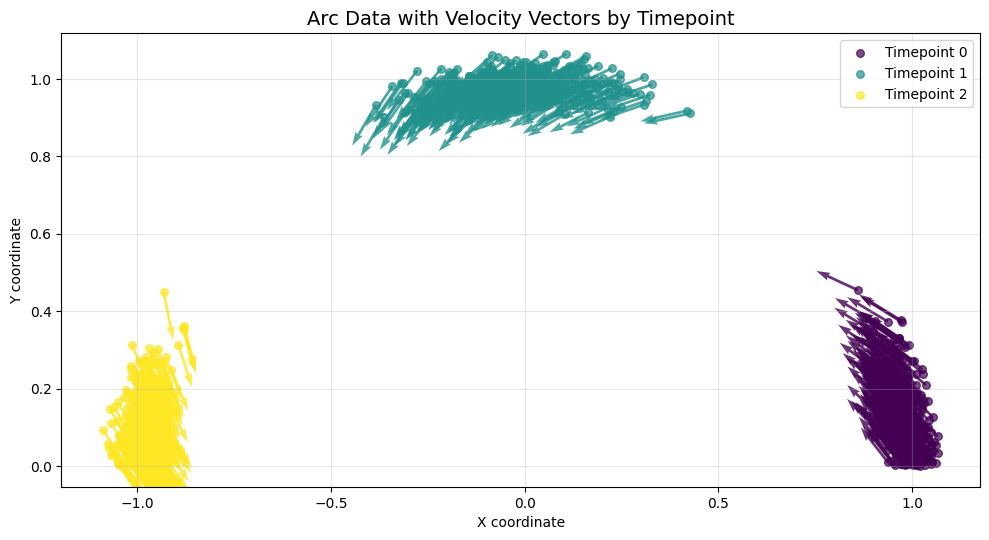

In [6]:
# Create the arc data generator with custom parameters

arc_gen = ArcDataGenerator(
    n_per_class=1000,
    noise_r=0.03,
    noise_theta=0.15,
    num_timepoints=3
)

# Generate the data
data, velocities, labels = arc_gen.generate_arc_data("arc_data.npz")

# Show the visualization
arc_gen.visualize_data()



In [3]:
!python -m TrajectoryNet.main \
              --dataset arc_data.npz --embedding_name phate \
              --niter 900 --batch_size 1000 \
              --leaveout_timepoint 1 \
              --training_noise 0 \
              --vecint 0 --top_k_reg 0 --interp_reg 0 \
              --save results


2025-06-24 11:19:46.526098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750763986.545215    2631 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750763986.551053    2631 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
True
/content/TrajectoryNet/TrajectoryNet/main.py
""" main.py

Learns ODE from scrna data with comprehensive evaluation

"""
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time

import torch
import torch.nn.functional as F
import torch.optim as optim

from TrajectoryNet.lib.growth_net import GrowthNet
from TrajectoryNet.lib import utils
from TrajectoryNet.lib.visualize_flow import visualize_tran

In [7]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive('results_zip', 'zip', 'results')

# Download the zip file
files.download('results_zip.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
!python -m TrajectoryNet.main \
              --test \
              --dataset arc_data.npz --embedding_name phate \
              --save results \
              --eval_visualize


2025-06-24 11:46:21.017180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750765581.038366    9118 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750765581.044915    9118 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
True
/content/TrajectoryNet/TrajectoryNet/main.py
""" main.py

Learns ODE from scrna data with comprehensive evaluation

"""
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time

import torch
import torch.nn.functional as F
import torch.optim as optim

from TrajectoryNet.lib.growth_net import GrowthNet
from TrajectoryNet.lib import utils
from TrajectoryNet.lib.visualize_flow import visualize_tran

In [5]:
!python -m TrajectoryNet.main \
              --dataset arc_data.npz --embedding_name phate \
              --test \
              --save results \
              --plot_trajectories

2025-06-24 11:47:15.439544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750765635.460411    9355 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750765635.466493    9355 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
True
/content/TrajectoryNet/TrajectoryNet/main.py
""" main.py

Learns ODE from scrna data with comprehensive evaluation

"""
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import time

import torch
import torch.nn.functional as F
import torch.optim as optim

from TrajectoryNet.lib.growth_net import GrowthNet
from TrajectoryNet.lib import utils
from TrajectoryNet.lib.visualize_flow import visualize_tran